# IMPORTS

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ghibtools as gh
import pingouin as pg
from scipy.stats import spearmanr
import os 

from configuration import *
from analyse_memory import *
from anova_permutation import anova_permutation


c:\Users\marion.walter\.virtualenvs\study2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# CODE

## Complementary Analysis - initial retrieval 

Check for memory performances equivalency at initial retrieval

Note : in the following dataframe, learning order columns contains 'E1' corresponding to 'Encoding 1' or Learning 1, and 'E2' corresponding to 'Encoding 2' or Learning 2

### get dataframe

In [2]:
df = get_all_trials_data_with_trial_numbers()
df_grouped = df.groupby(['subject', 'condition', 'order', 'learning_order', 'phase']).agg({
    'score': 'mean'
}).reset_index()

df = df_grouped[df_grouped['phase'] == 'initial']

phase == 'E1'
phase == 'E2'
phase == 'R1'
phase == 'R2'
phase == 'RF'


### ANOVA PERMUTATION - CONDITION AND LEARNING ORDER

In [4]:
anova_permutation(
        data=df,
        dependent_variable='score',
        within_factors=["learning_order", 'condition'],
    random_factor="subject",
    )

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In Sys.setlocale("LC_ALL", "English_United States.UTF-8") :  
R callback write-console: 
   
R callback write-console:  using locale code page other than 1252 may cause problems
  


Metadata features ['order', 'phase'] are not used in the model
Mixed design detected: 'method' has been overridden and set to 'Rd_kheradPajouh_renaud'.
Model formula : score ~ learning_order * condition + Error(subject/(learning_order * condition))

Resampling test using Rd_kheradPajouh_renaud to handle nuisance variables and 5000 permutations.
                               SSn dfn    SSd dfd      MSEn    MSEd         F
learning_order           1.092e-01   1 0.3351  28 1.092e-01 0.01197 9.125e+00
condition                4.267e-04   1 0.3351  28 4.267e-04 0.01197 3.565e-02
learning_order:condition 4.930e-32   1 1.1285  28 4.930e-32 0.04030 1.223e-30
                         parametric P(>F) resampled P(>F)
learning_order                   0.005335          0.0052
condition                        0.851610          0.8486
learning_order:condition         1.000000          1.0000



{'y': {'1': 0.64,
  '3': 0.88,
  '5': 0.84,
  '7': 0.64,
  '9': 0.56,
  '11': 0.44,
  '13': 0.8,
  '15': 0.88,
  '17': 0.84,
  '19': 0.6,
  '21': 0.96,
  '23': 0.68,
  '25': 0.76,
  '27': 0.64,
  '29': 1.0,
  '31': 1.0,
  '33': 1.0,
  '35': 0.96,
  '37': 1.0,
  '39': 0.92,
  '41': 0.64,
  '43': 0.8,
  '45': 0.84,
  '47': 0.92,
  '49': 0.72,
  '51': 0.8,
  '53': 0.72,
  '55': 0.96,
  '57': 0.52,
  '59': 0.76,
  '61': 0.92,
  '63': 0.52,
  '65': 0.72,
  '67': 0.72,
  '69': 0.88,
  '71': 0.84,
  '73': 0.52,
  '75': 0.8,
  '77': 1.0,
  '79': 0.96,
  '81': 0.44,
  '83': 0.56,
  '85': 0.84,
  '87': 0.96,
  '89': 0.52,
  '91': 0.6,
  '93': 0.92,
  '95': 0.84,
  '97': 0.88,
  '99': 0.72,
  '101': 0.64,
  '103': 0.72,
  '105': 0.88,
  '107': 0.88,
  '109': 0.44,
  '111': 0.76,
  '113': 0.92,
  '115': 0.96,
  '117': 0.76,
  '119': 0.56},
 'model.matrix': array([[ 1.,  1.,  1.,  1.],
        [ 1., -1., -1.,  1.],
        [ 1., -1.,  1., -1.],
        [ 1.,  1., -1., -1.],
        [ 1.,  1.,  1., 

### A few figures for data exploration, not used in the article

               T  dof alternative     p_val           CI95   cohen_d  \
T_test -0.088216   28   two-sided  0.930333  [-0.13, 0.12]  0.032212   

           power   BF10  
T_test  0.050833  0.345  
{'p': np.float64(0.9303327530634125), 'es': None, 'es_label': None, 'es_interp': None}


c:\Users\marion.walter\.virtualenvs\study2\Lib\site-packages\ghibtools\stats.py:411: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data = df, x = predictor, y = outcome, order = order, hue_order=[True, False], split=True, ax=ax, palette = palette, inner='box', alpha=0.2, cut=0) # construct basic ax without annotation


Text(0.5, 0.98, 'Comparison of Scores between Conditions for Learning 1')

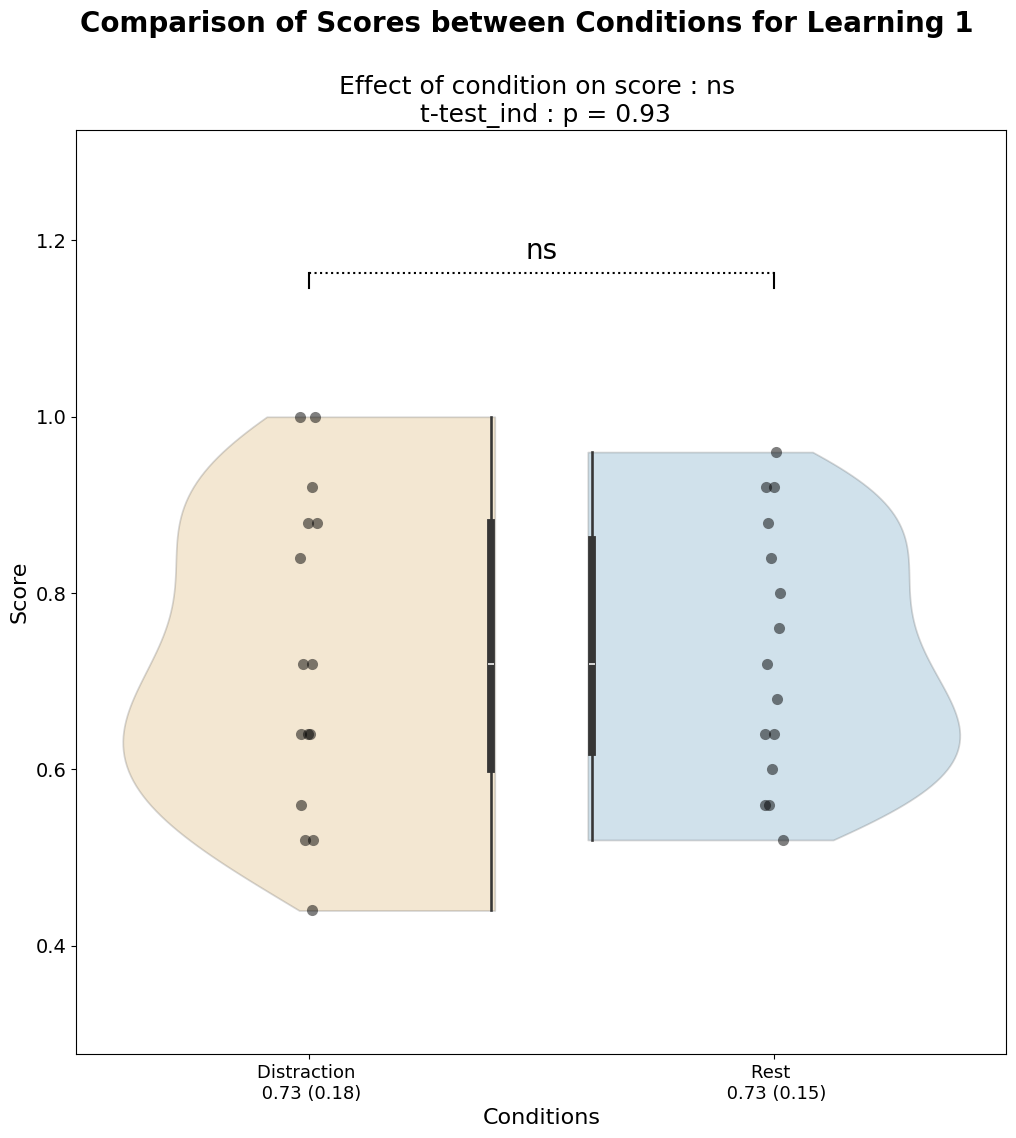

In [5]:
sub_df = df[df['learning_order'] == 'E1']

fig, ax = plt.subplots(figsize=(12, 12))

colors = sns.color_palette('colorblind')
order = ['Rest', 'Distraction']

palette={'Rest':  colors[0], 'Distraction': colors[1]}

gh.auto_stats(sub_df, 
              outcome='score', 
              design='between',
              palette=palette,
              predictor='condition',
              return_pval=True,
              fontsize=18,
              ax=ax)

ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('Conditions')
ax.set_ylabel('Score')

fig.suptitle('Comparison of Scores between Conditions for Learning 1', fontsize=20, fontweight='bold')


          W_val alternative     p_val       RBC      CLES
Wilcoxon   83.0   two-sided  0.011163 -0.560847  0.346111
{'p': np.float64(0.011162553342003936), 'es': np.float64(0.3461111111111111), 'es_label': 'CLES', 'es_interp': 'S'}


Text(0.5, 0.98, 'Score at Initial Recall for both Learning Phases')

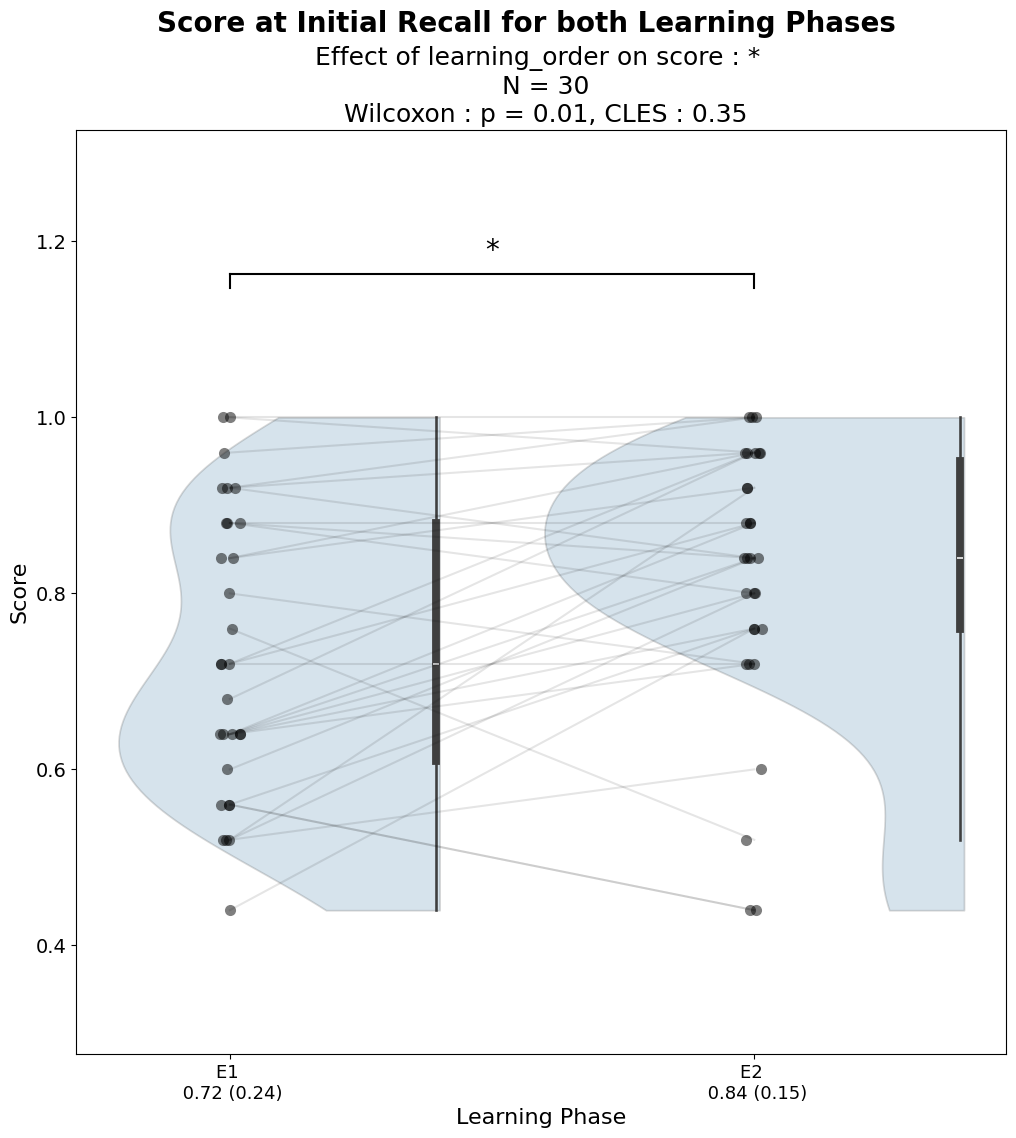

In [6]:
fig, ax = plt.subplots(figsize=(12, 12))

colors = sns.color_palette('colorblind')
order = ['Rest', 'Distraction']

palette={'Rest':  colors[0], 'Distraction': colors[1]}

gh.auto_stats(df, 
              outcome='score', 
              design='within',
              subject='subject',
              predictor='learning_order',
              return_pval=True,
              fontsize=18,
              ax=ax)

ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('Learning Phase')
ax.set_ylabel('Score')

fig.suptitle('Score at Initial Recall for both Learning Phases', fontsize=20, fontweight='bold')


               T  dof alternative     p_val           CI95   cohen_d  \
T_test -1.260278   14   two-sided  0.228171  [-0.23, 0.06]  0.565087   

           power   BF10  
T_test  0.530926  0.512  
{'p': np.float64(0.22817098462984825), 'es': None, 'es_label': None, 'es_interp': None}
          W_val alternative     p_val       RBC      CLES
Wilcoxon   34.0   two-sided  0.147124 -0.433333  0.322222


Text(0.5, 0.98, 'Score at Initial Retrieval for both Rest conditions')

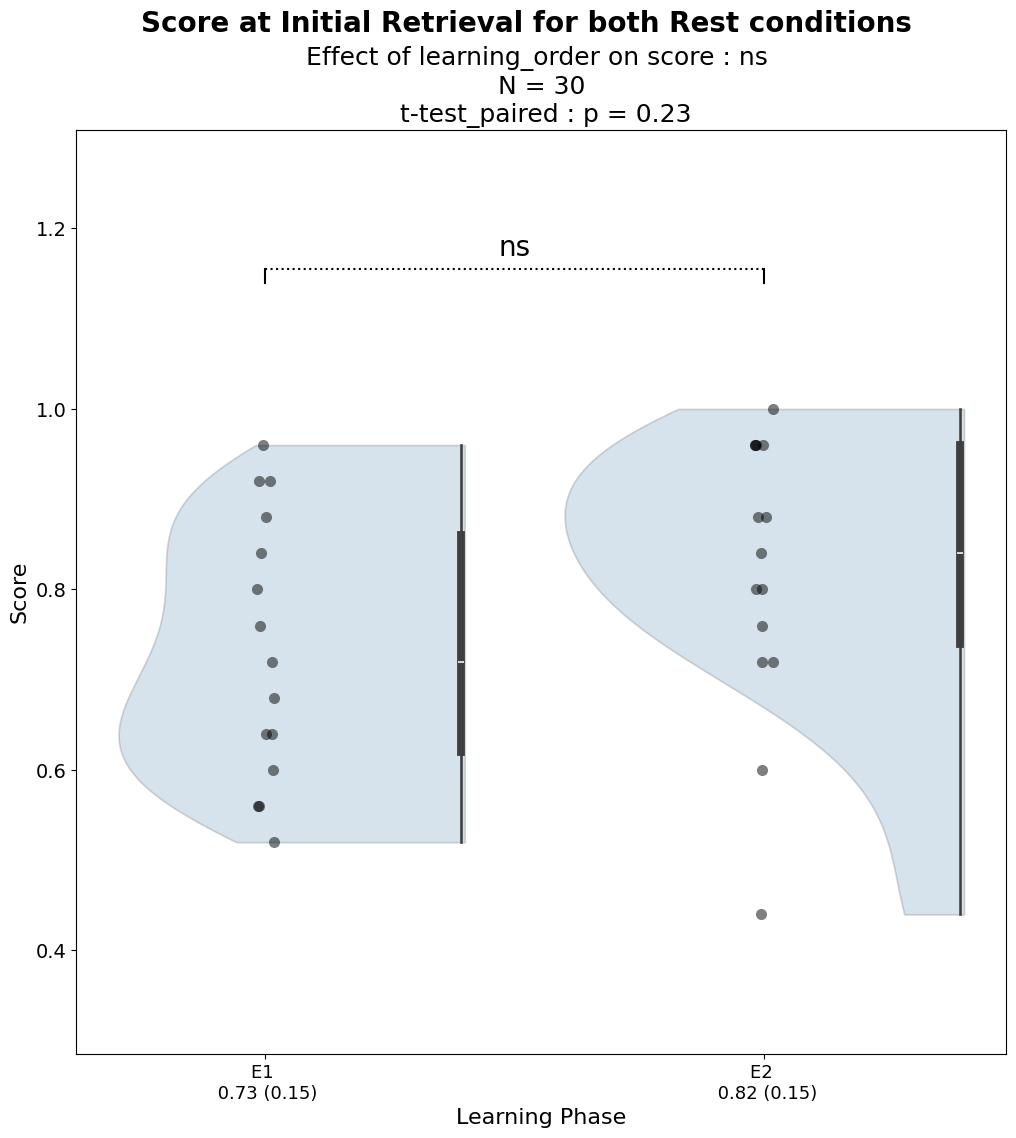

In [ ]:
sub_df = df[df['condition'] == 'Rest']

fig, ax = plt.subplots(figsize=(12, 12))

colors = sns.color_palette('colorblind')
order = ['E1', 'E2']

palette={'E1':  colors[0], 'E2': colors[1]}

gh.auto_stats(sub_df, 
              outcome='score', 
              design='within',
              subject='subject',
              # palette=palette,
              predictor='learning_order',
              order=order,
              return_pval=True,
              fontsize=18,
              ax=ax)

ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('Learning Phase')
ax.set_ylabel('Score')

fig.suptitle('Score at Initial Retrieval for both Rest conditions', fontsize=20, fontweight='bold')

               T  dof alternative     p_val          CI95   cohen_d     power  \
T_test -1.538583   14   two-sided  0.146197  [-0.2, 0.03]  0.497079  0.433794   

         BF10  
T_test  0.693  
{'p': np.float64(0.14619738433448104), 'es': None, 'es_label': None, 'es_interp': None}


c:\Users\marion.walter\.virtualenvs\study2\Lib\site-packages\ghibtools\stats.py:411: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data = df, x = predictor, y = outcome, order = order, hue_order=[True, False], split=True, ax=ax, palette = palette, inner='box', alpha=0.2, cut=0) # construct basic ax without annotation


Text(0.5, 0.98, 'Score at Initial Retrieval for both Distraction conditions')

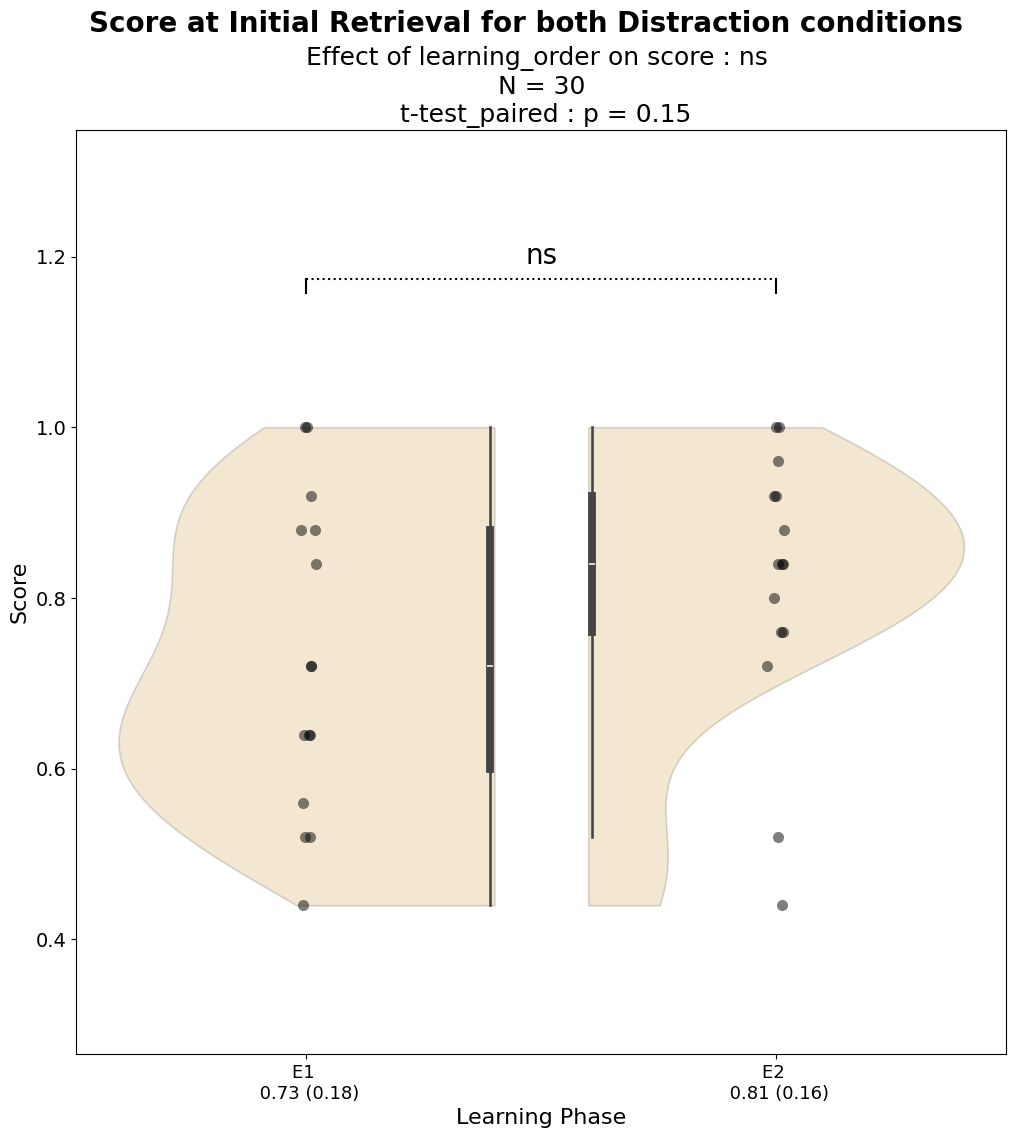

In [8]:
sub_df = df[df['condition'] == 'Distraction']

fig, ax = plt.subplots(figsize=(12, 12))

colors = sns.color_palette('colorblind')
order = ['E1', 'E2']

palette={'E1':  colors[1], 'E2': colors[1]}

gh.auto_stats(sub_df, 
              outcome='score', 
              design='within',
              subject='subject',
              palette=palette,
              predictor='learning_order',
              order=order,
              return_pval=True,
              fontsize=18,
              ax=ax)

ax.tick_params(axis='y', labelsize=14)
ax.set_xlabel('Learning Phase')
ax.set_ylabel('Score')

fig.suptitle('Score at Initial Retrieval for both Distraction conditions', fontsize=20, fontweight='bold')